<a href="https://colab.research.google.com/github/kailiwheeler/dsa425/blob/main/PCA_Food_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import svd
import seaborn as sns

## Part 1

In [3]:
df = pd.read_csv('Food_consumption.csv',index_col='Country')
df_high = (df[df['Income_level']=='High'])
print(df[df['Income_level']=='High'].index)
df_low = df[df['Income_level']=='Low']
print(df[df['Income_level']=='Low'].index)


Index(['Chile', 'Mexico'], dtype='object', name='Country')
Index(['Afghanistan', 'Armenia', 'Burkina Faso', 'Ethiopia ', 'Malawi', 'Mali',
       'Niger', 'Nigeria', 'Pakistan', 'Senegal', 'Somalia', 'Togo'],
      dtype='object', name='Country')


## Part 2: Data Exploration

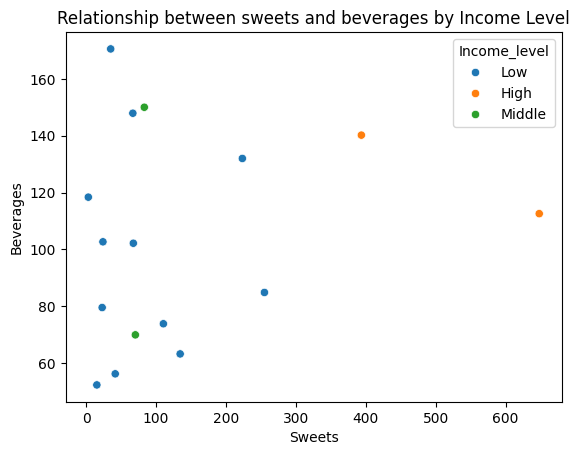

In [25]:
sns.scatterplot(data=df, x='eggs', y='meat', hue='Income_level')
plt.xlabel('Eggs')
plt.ylabel('Dairy')
plt.title('Relationship between eggs and dairy by Income Level')
plt.show()

In [ ]:
sns.scatterplot(data=df, x='seafood',y='tuber',hue='Income_level')
plt.xlabel('Seafood')
plt.ylabel('Tuber')
plt.title('Relationship between seafood and tuber by Income Level')
plt.show()

In [ ]:
sns.scatterplot(data=df, x='beverages', y='vegetables', hue='Income_level')
plt.xlabel('Beverages')
plt.ylabel('Vegetables')
plt.title('Relationship between beverages and vegetables by Income Level')
plt.show()

## Part 2: PCA

In [8]:
df_reduced = df.drop('Income_level', axis = 1)
df_scaled = (df_reduced - df_reduced.mean()) / df_reduced.std() #this is from the template
df_pca = PCA().fit(df_scaled)
df_scaled = df_scaled.dropna() #add this line right afterdf_pca = PCA().fit(df_scaled)
cores = df_pca.transform(df_scaled)
print(f"Proportion of variance explained by each principal component:\n{df_pca.explained_variance_ratio_}")


Proportion of variance explained by each principal component:
[0.35440169 0.21634952 0.13323964 0.0959137  0.05877018 0.05639165
 0.03756551 0.02008389 0.01508698 0.00655342 0.00319224 0.00245159]


## Part 2: Interpretation

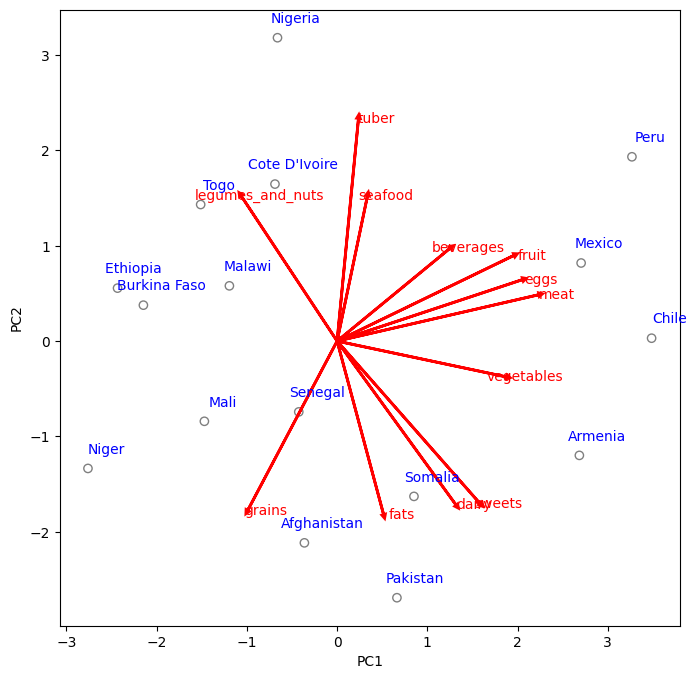

In [9]:
scores = df_pca.transform(df_scaled)
scale_factor = 5
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    scores[:, 0],
    scores[:, 1],
    color="none",
    edgecolor="k",
    alpha=0.5,
)
for i in range(df_pca.components_.shape[1]):
    ax.arrow(
        0,
        0,
        scale_factor*df_pca.components_[0, i],
        scale_factor*df_pca.components_[1, i],
        head_width=0.04,
        head_length=0.04,
        linewidth=2,
        color="red",
    )
    ax.text(
        scale_factor*df_pca.components_[0, i] + .2,
        scale_factor*df_pca.components_[1, i],
        df_reduced.columns[i],
        color="red",
        ha="center",
        va="center",
    )
for i in range(scores.shape[0]):
    ax.text(
        scores[i, 0] + 0.2,
        scores[i, 1] + 0.2,
        df_scaled.index[i],
        color="blue",
        ha="center",
        va="center",
    )
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

a)  how much of the variation is described by just the first dimension, and just the first 2 dimensions combined

b) your interpretation of the meaning of the PCA axes, as well as the reasoning behind your interpretation, based on the arrows (each arrow should be labeled with one of the original features of the dataset) and the countries. Describe the effect of income level on food consumption (refer to part 1 to remember which are the highest income countries and which are the lowest.) By the way, I found one of these axes relatively easy to interpret - the other was bit harder, but I think it is possible to figure out what it represents. Or at least I can guess. I'll be curious to see your interpretation; it's OK if it differs from mine as long as you can justify your answer based on the visualization.

c) Summarize what we learn about patterns of food consumption from the PCA process. What is the most important factor to describe variation in food consumption patterns?